# Project 1 — Census Income EDA & Modeling
**Author:** Noah Franscella
**Course:** IS 4482 - 090
**Date:** 2025-11-30  


## Table of contents
1. Libraries and importing the dataset
2. High-level exploration of the dataset
3. Column-by-column exploration
4. Target variable exploration
5. Target exploration by predictors
6. Data encoding
7. Model building
8. Comparison to baseline
9. Final model recommendation

In [9]:
#Cell: Libraries and importing the dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, RocCurveDisplay, make_scorer
import joblib
import warnings
warnings.filterwarnings("ignore")
sns.set_style("whitegrid")


#Dataset
url = "https://raw.githubusercontent.com/matthewpecsok/4482_fall_2024/main/data/census.csv"
df = pd.read_csv(url)
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,y
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


Libraries are a collection of pre-written code that provides you with extra tools so you don't have to build everything yourself from scratch. Libraries are imported so we can use these tools in our programs.

numpy - Makes working with numerical data more efficient. Numpy handles arrays, mathmatical operations, and anything else that handles numbers. I need numpy it because the machine learning models as well as the preprocessing steps work best with the arrays.

pandas - It is used to load, view, clean and organize a dataset. It basically treats the data like an excel spreadsheet with rows and columns. I need panda to import the data as well as prepare the dataset before training the models.

matplotlib.pyplot - This is used for basic plotting and visualizations. I'm using it to create graphs that will help me to understand the data plus show the models performance.

sklearn - A lot of my project uses sklearn, which is a huge machine learning library. It has tools that split data, training models, evaluating them, and tuning hyperparameters.

seaborn - It builds on Matplotlib and makes visuals cleaner and more professional. I'm using it to create a clean grid style so charts are easier to read


In [10]:
#Cell: High-level exploration of the dataset
print("Rows, columns:", df.shape)
print("\nColumn names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values per column:\n", df.isna().sum())
print("\nBasic descriptive statistics:\n", df.describe().T)
print("\nMinimum values:\n",df.min(numeric_only=True))
print("\nMaximum values:\n",df.max(numeric_only=True))
print("\nMean values:\n", df.mean(numeric_only=True))
print("\nMedian values:\n", df.median(numeric_only=True))
print("\nStandard deviation:\n", df.std(numeric_only=True))

#Quick look at unique counts
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print("\nUnique value counts for categorical columns:")
for c in cat_cols:
  print(c,"->", df[c].nunique())

#First and Last 5 rows
print("\nPreview of the dataset (head):")
display(df.head())

print("\nLast rows of the dataset (tail):")
display(df.tail())

#Value counts
print("\nTarget distribution (y):")
print(df['y'].value_counts(dropna=False))

Rows, columns: (32561, 15)

Column names:
 ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'y']

Data types:
 age                int64
workclass         object
fnlwgt             int64
education         object
education-num      int64
marital-status    object
occupation        object
relationship      object
race              object
sex               object
capital-gain       int64
capital-loss       int64
hours-per-week     int64
native-country    object
y                 object
dtype: object

Missing values per column:
 age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
y                 0
dtype: int64

Basic descript

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,y
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K



Last rows of the dataset (tail):


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,y
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K



Target distribution (y):
y
<=50K    24720
>50K      7841
Name: count, dtype: int64


The exploration shows that this is a large, clean dataset and that it is ready for analysis. There are no missing values, which make preprocessing simple. The data has both numeric as well as categorical variables. Several of the numerical features, capital-gain and capital-loss are very skewed, most people having zeros with only a few large outliers, which may impact modeling.

The categorical columns are widely unique because of the values they contain. Obviously, some like sex only have a couple categories, while others have many, like native-country. This leads to one-hot encoding will most likely increase the number of features.

Finally, the target variable is imbalanced, with seemingly more people earning <=50k rather than people earning >50k. This imbalance is importnant to note as models may favor the majority class unless it's accounted for.

In summary, the dataset is clean but it also shows some skewed distributions, high cardinality categorical feature, as well as an imbalanced target, which are all important patterns for later modeling.

------
Column: age
Data type: int64
count    32561.000000
mean        38.581647
std         13.640433
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64


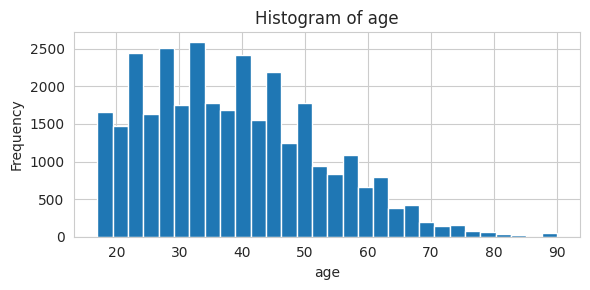

------
Column: workclass
Data type: object
------
Column: fnlwgt
Data type: int64
count    3.256100e+04
mean     1.897784e+05
std      1.055500e+05
min      1.228500e+04
25%      1.178270e+05
50%      1.783560e+05
75%      2.370510e+05
max      1.484705e+06
Name: fnlwgt, dtype: float64


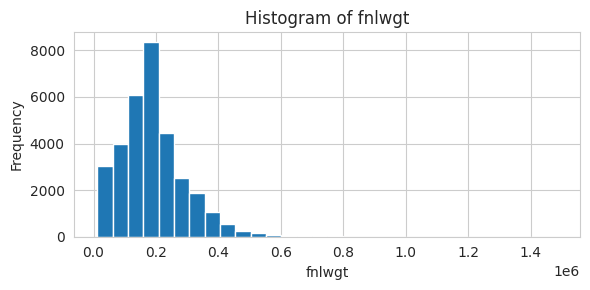

------
Column: education
Data type: object
------
Column: education-num
Data type: int64
count    32561.000000
mean        10.080679
std          2.572720
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-num, dtype: float64


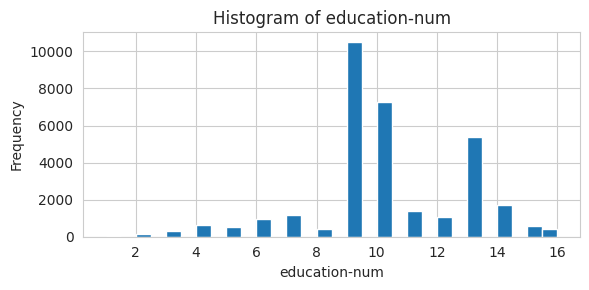

------
Column: marital-status
Data type: object
------
Column: occupation
Data type: object
------
Column: relationship
Data type: object
------
Column: race
Data type: object
------
Column: sex
Data type: object
------
Column: capital-gain
Data type: int64
count    32561.000000
mean      1077.648844
std       7385.292085
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64


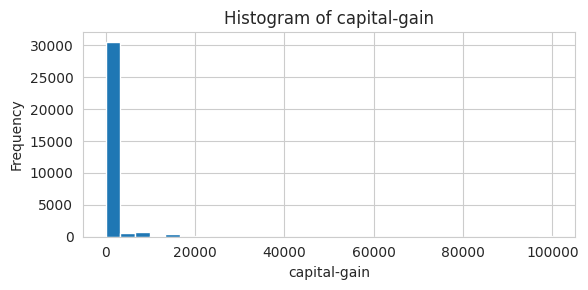

------
Column: capital-loss
Data type: int64
count    32561.000000
mean        87.303830
std        402.960219
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64


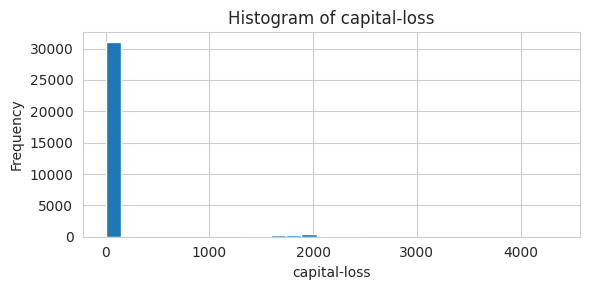

------
Column: hours-per-week
Data type: int64
count    32561.000000
mean        40.437456
std         12.347429
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64


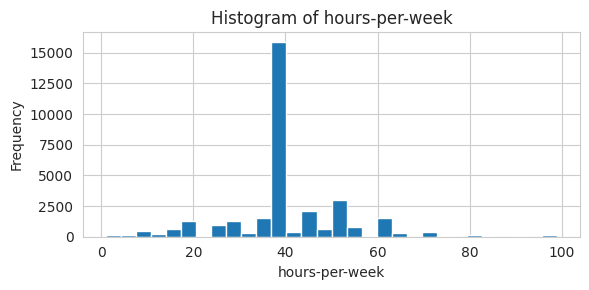

------
Column: native-country
Data type: object
Top categories:
 native-country
United-States    29170
Mexico             643
?                  583
Philippines        198
Germany            137
Canada             121
Puerto-Rico        114
El-Salvador        106
India              100
Cuba                95
Name: count, dtype: int64


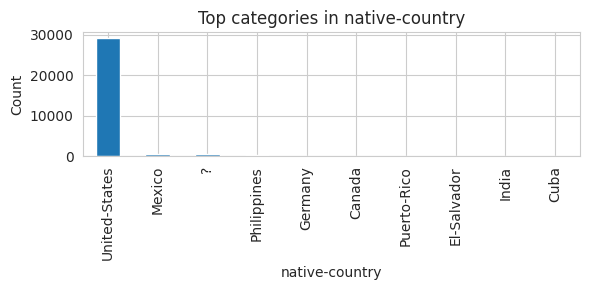

In [11]:
#Cell: Column-by-column exploration
import math
columns = [c for c in df.columns if c != 'y']
for c in columns:
  print("------\nColumn:", c)
  print("Data type:", df[c].dtype)
  if pd.api.types.is_numeric_dtype(df[c]):
    print(df[c].describe())

#Histogram
    plt.figure(figsize=(6,3))
    plt.hist(df[c].dropna(), bins=30)
    plt.title(f"Histogram of {c}")
    plt.xlabel(c)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()
else:
  vc = df[c].value_counts(dropna=False)
  print("Top categories:\n", vc.head(10))

  #Barplot
  plt.figure(figsize=(6,3))
  vc.head(10).plot(kind='bar')
  plt.title(f"Top categories in {c}")
  plt.xlabel(c)
  plt.ylabel("Count")
  plt.tight_layout()
  plt.show()

1. Age (Numeric) -
The age column has a range from 17 up to 90, with your average being about 38.5.Most of the individuals fall between their late 20s to late 40s. From this you can gather that this dataset is mostly representing working-age adults. The wide range also could help seperate different income levels later on.

2. Workclass (Categorical) - This categorical variable is describing the type of employment, whether it is pivate, government, or self employed. Since no numeric summary comes with it, it confirms that it is purely categorical.

3. Fnlwgt (Numeric) - fnlwgt has very large variation with values ranging from ~12,000 to larger than 1.4 million. Because fnlwgt is not an intuitive predictor and has this huge spread, it does not seem to be a very strong predictor for modeling, however the variation does indicate its design for survey weighting.

4. Education (Categorical) - This column contains level of education, so, HS grad, bachelors, assoc-acdm. Education should correlate with income, as education generally influences earning potential.

5. Education-num (Numeric) - This column represents the numeric representation of education. The median being 10, and the values ranging from 1-16, which corresponds to ones education level. The distribution is fairly centralized, suggesting that most people in the dataset have mid-range education. (likely highschool or some college)

6. Marital-status (Categorical) - Marital status is categorical and includes values such as married, never married, divorced. This may be a strong predictor as household structure typically relates to income level.

7. Occupation (Categorical) - Occupation covers job roles and you may see sales, tech support, managerial, etc. This has many categories which may create dummy variables after encoding. Occupations is highly related to earnings.

8. Relationship (Categorical) - This describes a person's status in the household; whether its husband, wife, unmarried, etc. Some of these relationship types are known to correlate with income.

9. Race (Categorical) - Race is once again another categorical type, and it includes groups like White, Black, etc. It can show patterns but they must be handled carefully.

10. Sex (Categorical) - Sex is a binary categorical variable, either male or female. Historically, income does differ between these groups, so it may be a predictive value.

11. Capital-gain (Numeric) - Capital-gain is very skewed: most of the values are 0, however there are some that are extremely high. This means only a small group has investments or asset-based income. For prediction, having a large capital gain is most likely associated with earning >50k.

12. Capital-loss (Numeric) - Similar to capital-gain,capital loss is also largely skewed with most values being 0. A small number of individuals do have notable losses. This is likely similar to capital-gain in the fact that having any nonzero value may differentiate higher-income levels of individuals.

13. Hours-per-week (Numeric) - Work hours mostly cluster around 40 hours. This suggests that most people are working full time. However there are a few outliers that either work extremely low or extremely high hours (1 to 99). The weekly hours worked to correlate with income level.

14. Native-country (Categorical) - Most of the individuals come from the United States, while all other countries have smaller counts. The imbalance here means one-hot encoding will create many sparse dummy variables for the rare countries. Ones native-country may play a role in earnings.

Notable patterns -

Numeric columns vary widely, while some (age, hours) are well distributed, and capital-gain/loss are largely skewed.

Many features are categorical and will require one-hot encoding

Columns like occupation, education, hours-per-week, and capital-gain are like strong income predictors.


y
<=50K    24720
>50K      7841
Name: count, dtype: int64
y
<=50K    0.75919
>50K     0.24081
Name: proportion, dtype: float64


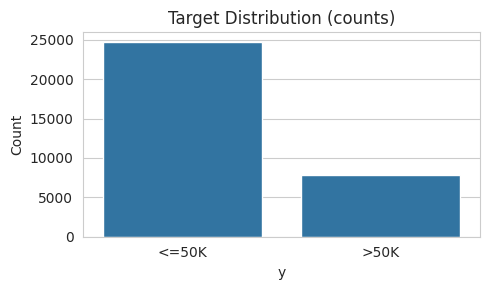

In [12]:
#Cell: Target Variable Exploration
target = 'y'
print(df[target].value_counts())
print(df[target].value_counts(normalize=True))

plt.figure(figsize=(5,3))
sns.countplot(x=target, data=df)
plt.title("Target Distribution (counts)")
plt.xlabel("y")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

1. This data mining task is a classification task since the target variable consists of distinct categories rather than just continuous numerical values. In classification, the goal is assigning each observation to one of several classes, an example of this is yes/no.

In contrast, regression predicts a continuous numerical value, like hours-per-week, or age. Regression models output real numbers while classification models output class probabilities.

2. Based on value counts, the target variable appears imbalanced. In my output, the majority class (<=50k) appears 24,720 times, while my minority class (>50k) appears 7,841 times.

Knowing this is important since an imbalanced target can make a model appear to be good even when it is not really learning anything useful. Since this is the case we would need to use evaluation metrics as well as modeling techniques that measure performance on both classes and not just on the one that is most popular.

3. Majority class count: 24720, Total observations = 32,561,
Majority accuracy = 24720/32561 = 0.759 or 75.9%

So the majority classifier will achieve 75.9% accuracy just by predicting the majority class. This means that any real model must perform better than the
75.9% accuracy.

4. Since the target variable is imbalanced, with the majority class making up 75.9%, accuracy is not the best metric.

Based on that I rank the F1-score as most important, followed by recall, precision, and accuracy.

F1-Score is the most important as the classes are imbalanced, the F1-score will give us a better picture of model performance.

I have recall next as it is important since we want to know how well the model identifies the minority class. If it has poor recall, it means it's missing most of the minority instances.

Precison comes third as it helps us to understand how many predicted positives are truly correct.

And finally accurcay is the least important as the majority class gurantees 75.9% accuracy without learning anything.

Categorical columns: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']
Numeric columns: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']


<Figure size 800x400 with 0 Axes>

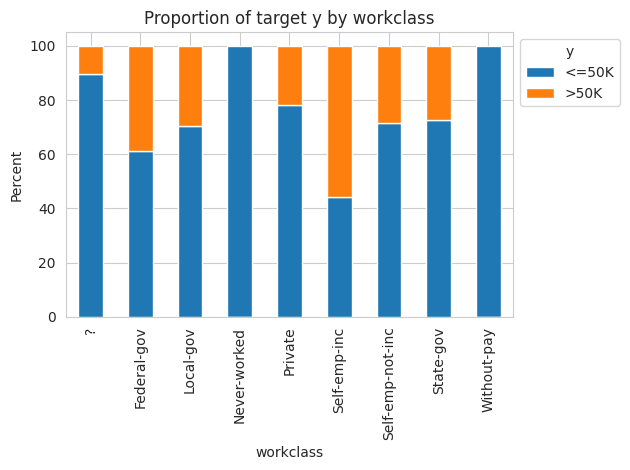

<Figure size 800x400 with 0 Axes>

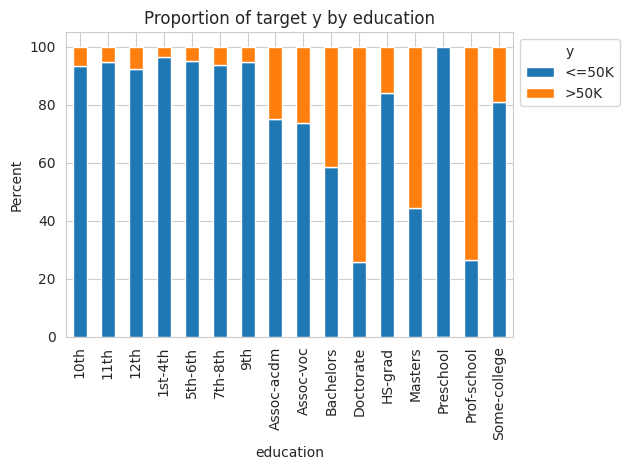

<Figure size 800x400 with 0 Axes>

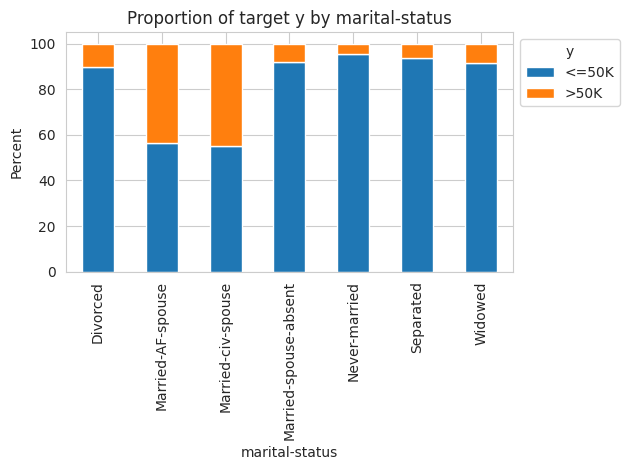

<Figure size 800x400 with 0 Axes>

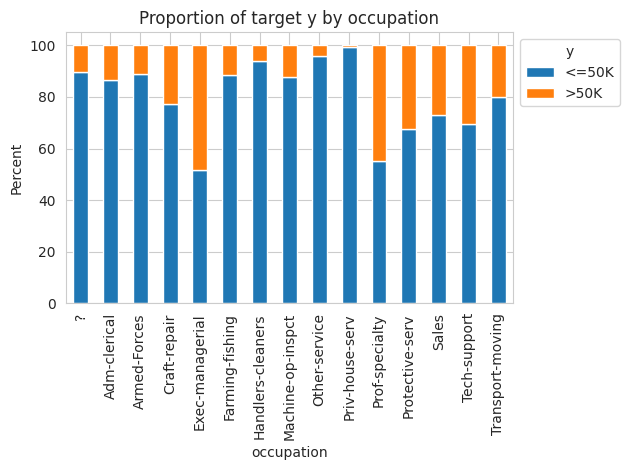

<Figure size 800x400 with 0 Axes>

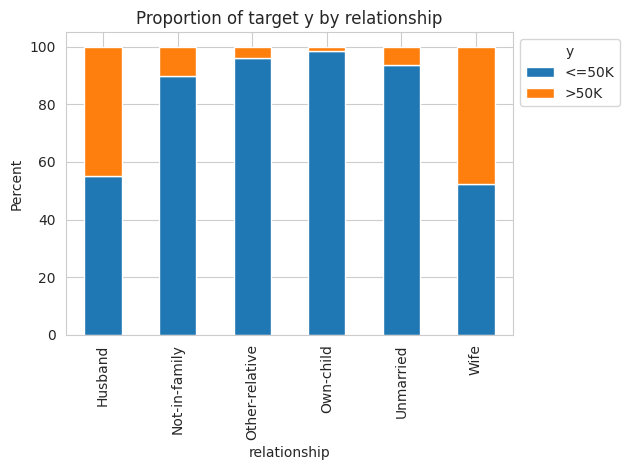

<Figure size 800x400 with 0 Axes>

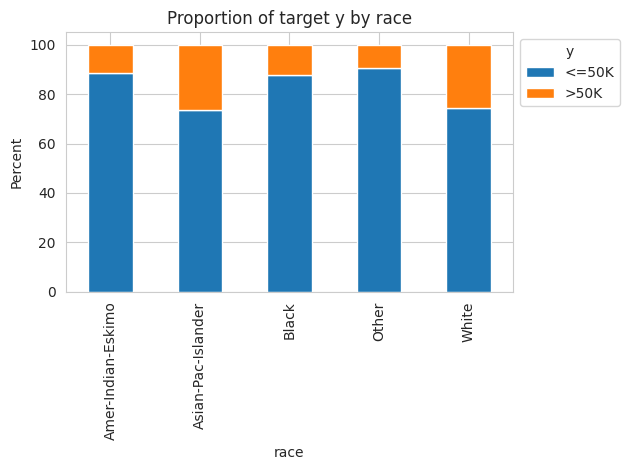

<Figure size 800x400 with 0 Axes>

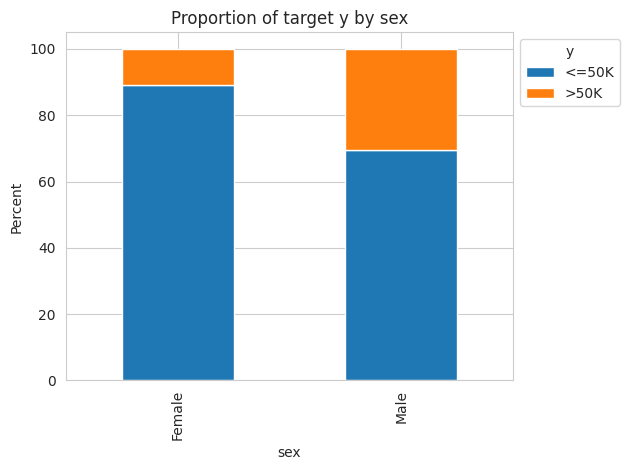

<Figure size 800x400 with 0 Axes>

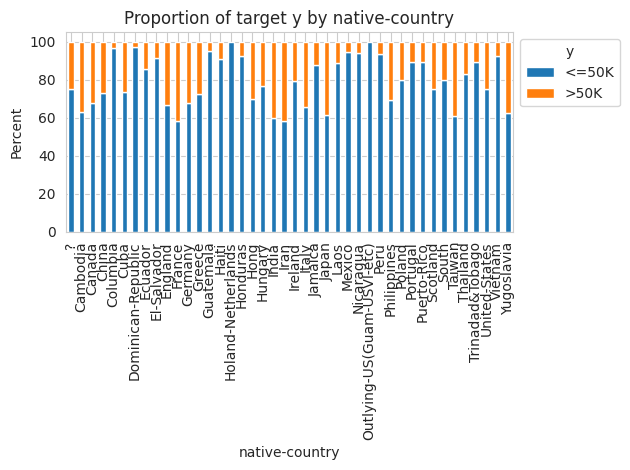

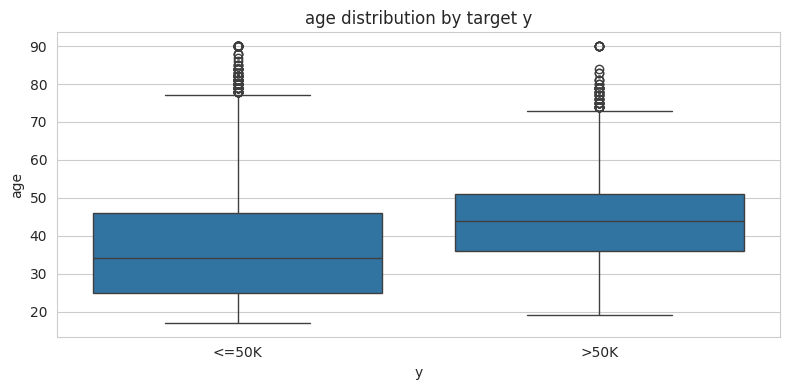

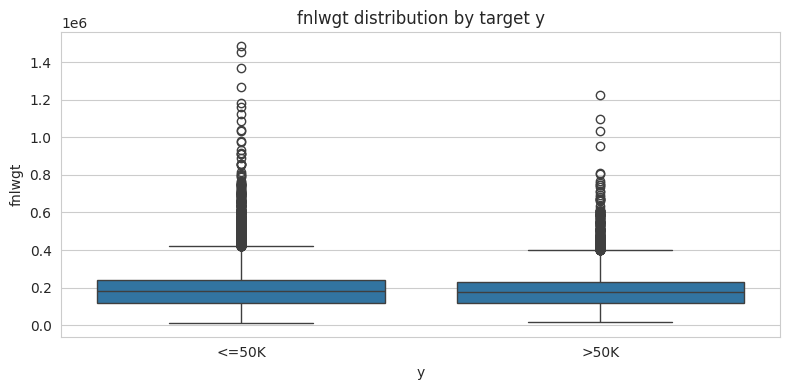

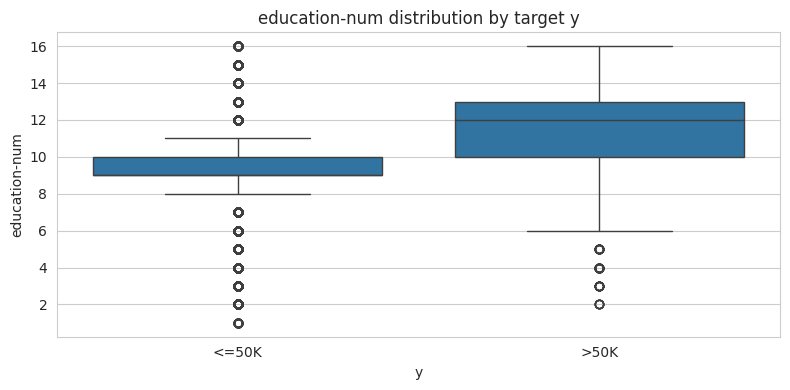

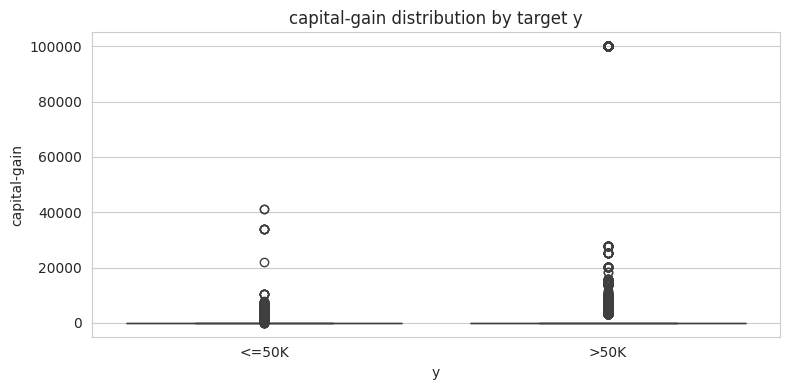

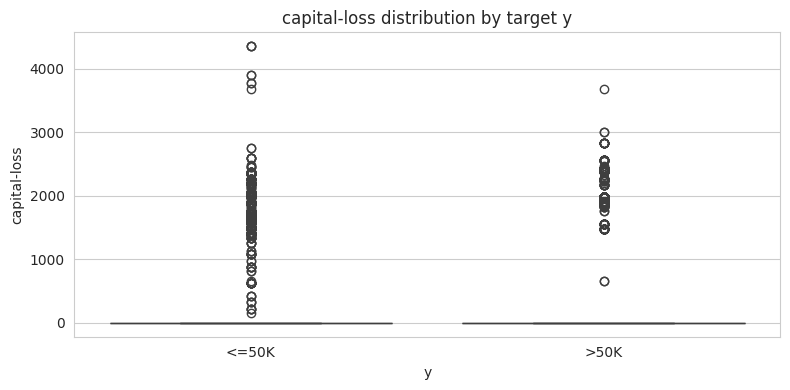

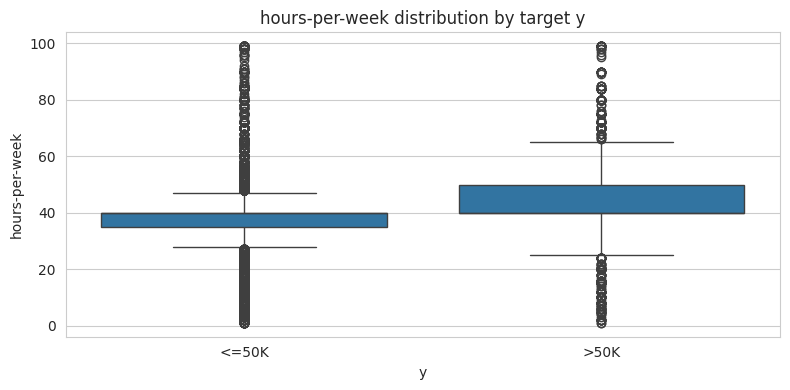

In [13]:
#Cell: Target exploration by predictors
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
%matplotlib inline


#List of predictors
predictors = [c for c in df.columns if c != 'y']

#Categorical vs Numerical
cat_cols = [c for c in predictors if df[c].dtype == 'object' or df[c].nunique() < 15]
num_cols = [c for c in predictors if c not in cat_cols]

print("Categorical columns:", cat_cols)
print("Numeric columns:", num_cols)

#Categorical: plot proportion of target
for col in cat_cols:
    plt.figure(figsize=(8,4))
    prop = (pd.crosstab(df[col], df['y'], normalize='index')*100).round(2)
    prop.plot(kind='bar', stacked=True)
    plt.title(f'Proportion of target y by {col}')
    plt.xlabel(col)
    plt.ylabel('Percent')
    plt.legend(title='y', bbox_to_anchor=(1,1))
    plt.tight_layout()
    plt.show()

#Numeric: boxplot per target class
for col in num_cols:
    plt.figure(figsize=(8,4))
    sns.boxplot(x='y', y=col, data=df)
    plt.title(f'{col} distribution by target y')
    plt.xlabel('y')
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()


1. Categorical Features

Several columns like; workclass, education, marital-status, occupation, and relationship show clear differences in the income outcomes across their categories compared to the target variable. In these categories, there are clear workclasses that make more, education levels that make more, etc.

Education, workclass, marital status, occupation, and relationship show obvious relationships with the target, meaning that models can use them effectively to destinguish between <=50k and >50k
2. Numerical Features

Age

The age variable reanges from 17 up to 90, with a mean of ~39 with a fairly large stddev of 13.6. The quartiles show that most individuals fall between the ages of 27 and 48, which suggests there is a broad working age population.

Fnlwgt

The fnlwgt variable has a wide range from 12,285 up to 1.48M, with a high stddev relative to the mean. This is indicating a highly skewed distribution. Since this variable is typically considered less important it may require scaling or removal depending on it impacts later on.

Education-num
This ranges from 1-16, with a mean of ~10. The values appear consistent and evenly spaced indicationg an ordinal variable. It's likely a more reliable numeric representation of education than the categorical column education.

Capital-gain

Capital-gain is heavily skewed. With the mean being around 1077, but the median and quartiles up to the 75th percentile are 0. With the maximum being 99,999 we can confirm there are significant outliers.

Capital-loss

Similar to capital-gain, capital-loss is heavily skewed with most reporting 0. There are however a few individuals with losses up to 4,356, suggesting that the outliers may influence the model if they are not handled carefully

Hours-per-week

The hours-per-week variable is fairly centered, with a min of 1 hour and a max of 99 hours. The median as well as the 25th percentile are both 40, showing that the typical full-time work week dominates in the dataset. The distribution does have some spread above 40 hours, so this might help distinguish higher-income individuals.

In [14]:
#Cell: Data encoding
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Make a copy of df and pop target
df_model = df.copy()
y = df_model.pop('y')


if y.dtype == 'object':
    y_encoded = (y == '>50K').astype(int)
else:
    y_encoded = y.copy()

print("Original shape:", df.shape)
print("Predictor dataframe shape before encoding:", df_model.shape)

#Identify categorical and numeric for encoder
categorical_cols = [c for c in df_model.columns if df_model[c].dtype == 'object' or df_model[c].nunique() < 15]
numeric_cols = [c for c in df_model.columns if c not in categorical_cols]

from sklearn.preprocessing import StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ], remainder='drop'
)

#Fit-transform to show encoded shape
X_encoded = preprocessor.fit_transform(df_model)

try:
    ohe_cols = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    out_cols = list(numeric_cols) + list(ohe_cols)
except Exception:
    #fallback: approximate column count only
    out_cols = None

import numpy as np
print("Encoded X shape:", X_encoded.shape)
if out_cols is not None:
    print("Number of output features:", len(out_cols))
else:
    print("Output feature names unavailable in this sklearn version; use shape to infer columns.")


Original shape: (32561, 15)
Predictor dataframe shape before encoding: (32561, 14)
Encoded X shape: (32561, 100)
Number of output features: 100


For this task I seperate the traget column and converted it to a binary variable. After that I split the predictors into both numeric and categorical features, scaling the numeric ones and one-hot encoding the categoricals. After encoding the dataset expanded from its measily 14 predictors to 100 total, creating a fully numeric dataset that is ready for modeling.

In [24]:
#Cell: Model Building
#Global setup

X = X_encoded.astype(np.float32)
y = y_encoded.values if hasattr(y_encoded, "values") else np.array(y_encoded)

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

scoring = {
    'accuracy': 'accuracy',
    'precision': make_scorer(precision_score, zero_division=0),
    'recall': make_scorer(recall_score, zero_division=0),
    'f1': make_scorer(f1_score, zero_division=0),
    'roc_auc': 'roc_auc'
}

results_summary = {}



In [25]:
#Dummy Model

dummy = DummyClassifier(strategy='most_frequent')

dummy_scores = cross_validate(
    dummy,
    X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=2
)

results_summary['Dummy'] = {
    m: np.mean(dummy_scores[f'test_{m}'])
    for m in scoring
}

In [26]:
#Decision Tree

dt_pipe = Pipeline([
    ('clf', DecisionTreeClassifier(random_state=42))
])

dt_param_grid = {
    'clf__max_depth': [3, 8, None],
    'clf__min_samples_split': [2, 10],
    'clf__criterion': ['gini']
}

dt_grid = GridSearchCV(
    dt_pipe,
    dt_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=2
)

dt_grid.fit(X, y)

dt_best = dt_grid.best_estimator_

dt_scores = cross_validate(
    dt_best,
    X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=2
)

results_summary['DecisionTree'] = {
    m: np.mean(dt_scores[f'test_{m}'])
    for m in scoring
}

print("DecisionTree best params:", dt_grid.best_params_)


DecisionTree best params: {'clf__criterion': 'gini', 'clf__max_depth': 8, 'clf__min_samples_split': 2}


In [27]:
#KNN

knn_pipe = Pipeline([
    ('clf', KNeighborsClassifier())
])

knn_param_grid = {
    'clf__n_neighbors': [5, 9],
    'clf__weights': ['uniform'],
    'clf__p': [2]
}

knn_grid = GridSearchCV(
    knn_pipe,
    knn_param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=2
)

knn_grid.fit(X, y)

knn_best = knn_grid.best_estimator_

knn_scores = cross_validate(
    knn_best,
    X, y,
    cv=cv,
    scoring=scoring,
    n_jobs=2
)

results_summary['KNN'] = {
    m: np.mean(knn_scores[f'test_{m}'])
    for m in scoring
}

print("KNN best params:", knn_grid.best_params_)


KNN best params: {'clf__n_neighbors': 9, 'clf__p': 2, 'clf__weights': 'uniform'}


In [32]:
# Linear SVM

from sklearn.svm import LinearSVC

svc = LinearSVC(
    C=1,
    max_iter=5000,
    random_state=42
)

svc_scores = cross_validate(
    svc,
    X.astype(np.float32),
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=2
)

results_summary['SVM'] = {
    m: np.mean(svc_scores[f'test_{m}'])
    for m in scoring
}



In [36]:
#MLP

mlp = MLPClassifier(
    hidden_layer_sizes=(50,),
    max_iter=100,
    alpha=0.001,
    activation='relu',
    random_state=42
)

mlp_scores = cross_validate(
    mlp,
    X.astype(np.float32),
    y,
    cv=cv,
    scoring=scoring,
    n_jobs=2
)

results_summary['MLP'] = {
    m: np.mean(mlp_scores[f'test_{m}'])
    for m in scoring
}




In [37]:
summary_df = pd.DataFrame(results_summary).T
display(summary_df.round(4))


,accuracy,precision,recall,f1,roc_auc
Dummy,0.7592,0.0000,0.0000,0.0000,0.5000
DecisionTree,0.8552,0.7907,0.5421,0.6433,0.9009
KNN,0.8372,0.6819,0.6071,0.6423,0.8797
SVM,0.8511,0.7390,0.5904,0.6563,0.9061
MLP,0.8482,0.6989,0.6503,0.6733,0.9061


**Comparison to Baseline**

The dummy classifier attained a relatively high accuracy of 75.9% however it produced zeros for precision, recall, and f1 score, verifying that this is due to class imbalances as well as random guessing. Among the data models, the MLP attained the best performance overall. With the highest f1 score of 0.6733, as well as tying for the highest roc_auc score of 0.9061. This indicates the best balance between detecting high income individuals plus limiting false positives. The SVM performed similarly, achieving an f1 score of 0.6563 and an equal roc_auc of 0.9061. On the other hand, the decision tree did have the highest precision at 0.7907 which means that it is the most accurate when predicting high income, however, its low recall of 0.5421 indicates that it missed many positive cases. Now, KNN did produce a reasonably balanced performance, but it just did not outperform the SVM or MLP models. Overall, the MLP demonstrated to be the most effective predictive performance of the dataset.

**Final Model Recommendation**

The single model I recommend using for predicting the target is the MLP model. I recommended this model based on its cross-validated performance; the MLP achieved the highest f1-score of 0.6733 as well as the highest recall score of 0.6503 amongt the candidate models. On top of that, it tied for the best roc_auc score of 0.9061 with the SVM. F1 is the primary comparison metric as the dataset is imbalanced, and I know this since the dummy baseline produced 75.9% accuracy but held a 0 for the f1-score. The f1 balances precision and recall when both false positives and false negatives are important. With that, the MLP provides the best balance between correctly identifying positive cases and avoiding any false alarm.

The MLP was chosen over the other model options because of it consistently outperforming the other models with balancing detection strength and classification reliability. While the decision tree model did produce the highest precision score of 0.7907, its low recall metric led it to miss more positive cases, which in turn led to a lower f1-score. In use this would result in many of the high-income individuals being incorrectly classified as low income individuals. KNN performed moderately however it did not reach the same level of roc_auc or f1-score that was achieved by the MLP showing a weaker overall class distinction.

On the other hand, the SVM produced similar results to the MLP, matching its roc_auc score. In contrast, its slightly lower f1-score and recall indicate that it fails to identify as many true positive samples. Since the task emphasizes accurate identification across these classes rather than reducing one type of error, the MLP's stronger balance was what made it the preferred choice.



In [ ]:
!cp "/content/drive/My Drive/Colab Notebooks/P1_Franscella_Noah.ipynb" ./
!jupyter nbconvert --to html "P1_Franscella_Noah.ipynb"